# 11. Time-Series-Specific: Multivariate, Multi-Step & Lookback — Keras (RNN/LSTM)

Concepts that only apply to the **forecasting** side: using many features vs one, predicting several steps ahead, and how far back the model should look. (IMDB has no analogue — covered in 10.)

**Two datasets, one concept:**
- **A) IMDB** movie reviews — many-to-one *text classification* (metric: accuracy).
- **B) Jena Climate** weather — sliding-window *temperature forecasting* (metric: MAE).

> Data prep lives in `rnn_data.py`; run `01_sequence_data_prep` once to build the caches.

---

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import rnn_data as R                      # shared loaders (see rnn_data.py)
keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


In [2]:
def plot_history(h, metric, title=""):
    """Train (solid) vs validation (dashed): loss on the left, `metric` on the right."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], "--", label="val")
    ax[0].set_title(title + " — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h.history[metric], label="train")
    ax[1].plot(h.history["val_" + metric], "--", label="val")
    ax[1].set_title(title + " — " + metric); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 1. Univariate vs multivariate inputs

Does the model need all 14 weather channels, or is past temperature enough? We train one LSTM on **temperature only** and one on **all features**.

In [3]:
s = R.load_jena_series()
temp_idx = s["target_idx"]

def train_lstm(feature_idx, epochs=6):
    train_ds, val_ds, nfeat = R.make_jena_datasets(lookback=48, horizon=1,
                                                   batch_size=128, feature_idx=feature_idx)
    keras.utils.set_random_seed(42)
    m = keras.Sequential([keras.Input((None, nfeat)), layers.LSTM(32), layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    h = m.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0)
    return min(h.history["val_mae"])

uni  = train_lstm([temp_idx])
multi = train_lstm(None)
print("univariate  (temp only) : val MAE %.3f (~%.2f degC)" % (uni,   uni  * s["temp_std"]))
print("multivariate (14 feats) : val MAE %.3f (~%.2f degC)" % (multi, multi * s["temp_std"]))

univariate  (temp only) : val MAE 0.187 (~1.62 degC)
multivariate (14 feats) : val MAE 0.121 (~1.05 degC)


## 2. Multi-step forecasting

Instead of the next hour, predict the **next 24 hours** at once — a many-to-many head: the LSTM's final state feeds a `Dense(24)`.

In [4]:
train_ds, val_ds, nfeat = R.make_jena_datasets(lookback=72, multi_step=24, batch_size=128)
keras.utils.set_random_seed(42)
model = keras.Sequential([keras.Input((None, nfeat)), layers.LSTM(48), layers.Dense(24)])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
h = model.fit(train_ds, validation_data=val_ds, epochs=8, verbose=0)
print("24-hour forecast val MAE: %.3f (~%.2f degC)" % (min(h.history["val_mae"]),
                                                       min(h.history["val_mae"]) * s["temp_std"]))

24-hour forecast val MAE: 0.329 (~2.85 degC)


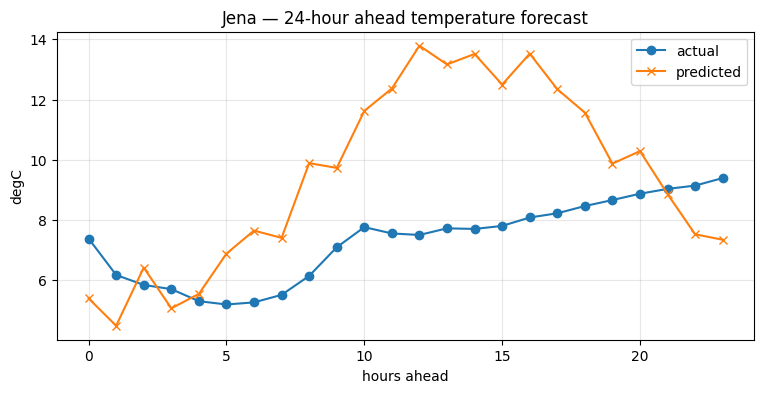

In [5]:
# plot one 24-hour forecast vs the truth (de-standardized)
xb, yb = next(iter(val_ds))
pred = model.predict(xb[:1], verbose=0)[0]
true = yb[0].numpy()
to_c = lambda z: z * s["temp_std"] + s["temp_mean"]
plt.figure(figsize=(9, 4))
plt.plot(range(24), to_c(true), marker="o", label="actual")
plt.plot(range(24), to_c(pred), marker="x", label="predicted")
plt.title("Jena — 24-hour ahead temperature forecast"); plt.xlabel("hours ahead")
plt.ylabel("degC"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 3. Lookback-window size

How many past hours should the model see? Too few misses context; too many adds noise and cost. We sweep the lookback and compare single-step MAE.

lookback  12 h -> val MAE ~ 1.19 degC


lookback  24 h -> val MAE ~ 1.08 degC


lookback  48 h -> val MAE ~ 1.08 degC


lookback  96 h -> val MAE ~ 1.09 degC


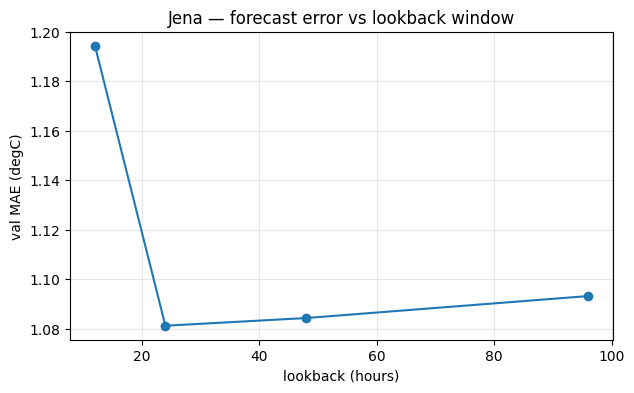

In [6]:
lookbacks = [12, 24, 48, 96]
mae_by_lb = []
for lb in lookbacks:
    train_ds, val_ds, nfeat = R.make_jena_datasets(lookback=lb, horizon=1, batch_size=128)
    keras.utils.set_random_seed(42)
    m = keras.Sequential([keras.Input((None, nfeat)), layers.LSTM(32), layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    h = m.fit(train_ds, validation_data=val_ds, epochs=5, verbose=0)
    mae_by_lb.append(min(h.history["val_mae"]) * s["temp_std"])
    print("lookback %3d h -> val MAE ~ %.2f degC" % (lb, mae_by_lb[-1]))

plt.figure(figsize=(7, 4))
plt.plot(lookbacks, mae_by_lb, marker="o")
plt.title("Jena — forecast error vs lookback window"); plt.xlabel("lookback (hours)")
plt.ylabel("val MAE (degC)"); plt.grid(alpha=.3); plt.show()

## Takeaways
- **Multivariate** inputs (pressure, humidity, wind, …) usually beat temperature-alone — related channels carry predictive signal.
- **Multi-step** forecasting is just a wider output head (`Dense(H)`); error grows with the horizon, and the forecast-vs-actual plot shows where it drifts.
- **Lookback** has a sweet spot: accuracy improves with more history up to a point, then flattens or worsens while cost keeps rising — sweep it rather than guessing.
- Together with notebook 10, this completes every RNN/LSTM concept across both a text and a time-series dataset.